# 请选择自己喜欢的5支股票构建投资组合，或者是从沪深300指数成分股中随机选择5-10只股票，画出走势图与组合的有效前沿。

（1）导出5只股票的收盘价格数据

（2）合并5只股票的收盘价数据

（3）画出5只股票的可比价格走势图

（4）计算每支股票的收益与风险

（5）求解投资组合的最优组合

（6）画出投资组合的有效前沿

（7）拓展从沪深300指数成分股中随机选择5-10只股票，画出他们的投资组合有效前沿

## (1).导出5只股票的收盘价格数据

In [84]:
import tushare as ts
pro = ts.pro_api('a394376ad4ede9c1214c06479e7d1bee32919045f909fcbfc39cabde')
BOC = pro.daily(ts_code='601988.SH', start_date='20240102', end_date='20250516')#中国银行
ICBC = pro.daily(ts_code='601398.SH', start_date='20240102', end_date='20250516')#工商银行
YMKD = pro.daily(ts_code='603259.SH', start_date='20240102', end_date='20250516')#药明康德
FXYY = pro.daily(ts_code='600196.SH', start_date='20240102', end_date='20250516')#复星医药
DFGY = pro.daily(ts_code='002167.SZ', start_date='20240102', end_date='20250516')#东方锆业
#SZZS = pro.daily(ts_code='000001', start_date='20250102', end_date='20250516')#上证指数

In [85]:
BOC

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,601988.SH,20250516,5.67,5.69,5.59,5.63,5.67,-0.04,-0.7055,2474331.18,1391039.113
1,601988.SH,20250515,5.69,5.73,5.66,5.67,5.68,-0.01,-0.1761,1863262.14,1060183.356
2,601988.SH,20250514,5.65,5.72,5.63,5.68,5.67,0.01,0.1764,2235242.06,1268937.972
3,601988.SH,20250513,5.63,5.69,5.58,5.67,5.63,0.04,0.7105,2179978.93,1231977.785
4,601988.SH,20250512,5.65,5.67,5.57,5.63,5.65,-0.02,-0.3540,2441703.00,1372758.468
...,...,...,...,...,...,...,...,...,...,...,...
324,601988.SH,20240108,4.12,4.15,4.08,4.10,4.12,-0.02,-0.4854,1863335.83,766636.713
325,601988.SH,20240105,4.14,4.19,4.10,4.12,4.14,-0.02,-0.4831,2148800.85,890404.786
326,601988.SH,20240104,4.05,4.15,4.04,4.14,4.05,0.09,2.2222,2563063.63,1049333.406
327,601988.SH,20240103,4.01,4.06,4.01,4.05,4.01,0.04,0.9975,1833776.60,741172.791


In [86]:
ICBC

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,601398.SH,20250516,7.26,7.30,7.12,7.16,7.27,-0.11,-1.5131,3935141.31,2821005.777
1,601398.SH,20250515,7.23,7.29,7.22,7.27,7.23,0.04,0.5533,2702620.63,1961219.204
2,601398.SH,20250514,7.23,7.28,7.20,7.23,7.23,0.00,0.0000,2868697.06,2076209.237
3,601398.SH,20250513,7.16,7.25,7.12,7.23,7.16,0.07,0.9777,2767459.46,1994786.847
4,601398.SH,20250512,7.15,7.18,7.11,7.16,7.17,-0.01,-0.1395,2702769.88,1932351.708
...,...,...,...,...,...,...,...,...,...,...,...
324,601398.SH,20240108,4.87,4.91,4.85,4.88,4.87,0.01,0.2053,3252257.28,1588242.673
325,601398.SH,20240105,4.89,4.94,4.86,4.87,4.89,-0.02,-0.4090,2860747.20,1403610.998
326,601398.SH,20240104,4.84,4.90,4.83,4.89,4.84,0.05,1.0331,2865675.59,1396443.521
327,601398.SH,20240103,4.79,4.85,4.78,4.84,4.79,0.05,1.0438,2488954.27,1201719.346


In [87]:
YMKD

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,603259.SH,20250516,61.00,61.40,60.40,61.36,61.39,-0.03,-0.0489,210076.50,1282031.356
1,603259.SH,20250515,61.10,62.34,60.80,61.39,61.03,0.36,0.5899,343115.70,2113666.550
2,603259.SH,20250514,60.19,61.28,59.62,61.03,59.86,1.17,1.9546,341428.47,2066253.521
3,603259.SH,20250513,60.60,60.61,59.70,59.86,59.41,0.45,0.7574,303866.93,1825329.067
4,603259.SH,20250512,58.00,59.98,58.00,59.41,59.06,0.35,0.5926,373049.30,2205959.520
...,...,...,...,...,...,...,...,...,...,...,...
324,603259.SH,20240108,67.83,68.18,67.10,67.46,68.11,-0.65,-0.9543,148078.40,999943.010
325,603259.SH,20240105,69.40,69.55,67.50,68.11,69.16,-1.05,-1.5182,177232.89,1214808.634
326,603259.SH,20240104,69.98,69.98,68.64,69.16,70.10,-0.94,-1.3409,210134.38,1451571.350
327,603259.SH,20240103,70.05,71.17,69.88,70.10,70.50,-0.40,-0.5674,142196.91,1000918.548


In [88]:
FXYY

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600196.SH,20250516,23.78,24.03,23.71,24.02,23.77,0.25,1.0517,125400.14,299892.390
1,600196.SH,20250515,23.91,23.97,23.75,23.77,23.91,-0.14,-0.5855,85862.58,204753.192
2,600196.SH,20250514,23.87,23.97,23.66,23.91,23.94,-0.03,-0.1253,97550.96,232171.156
3,600196.SH,20250513,23.68,24.04,23.63,23.94,23.59,0.35,1.4837,170553.76,406205.704
4,600196.SH,20250512,23.54,23.62,23.47,23.59,23.52,0.07,0.2976,109144.00,257012.413
...,...,...,...,...,...,...,...,...,...,...,...
324,600196.SH,20240108,24.51,24.58,24.18,24.21,24.55,-0.34,-1.3849,65467.75,159135.512
325,600196.SH,20240105,24.96,24.99,24.47,24.55,24.95,-0.40,-1.6032,74742.58,184740.335
326,600196.SH,20240104,24.98,25.07,24.67,24.95,24.97,-0.02,-0.0801,79181.01,196752.019
327,600196.SH,20240103,24.85,25.23,24.82,24.97,24.86,0.11,0.4425,87763.18,219739.867


In [89]:
DFGY

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,002167.SZ,20250516,9.00,9.28,9.00,9.07,9.04,0.03,0.3319,292407.43,267021.648
1,002167.SZ,20250515,9.26,9.26,9.02,9.04,9.28,-0.24,-2.5862,341982.02,311305.477
2,002167.SZ,20250514,9.33,9.40,9.20,9.28,9.34,-0.06,-0.6424,374051.34,346997.824
3,002167.SZ,20250513,9.49,9.51,9.32,9.34,9.49,-0.15,-1.5806,414144.00,388561.750
4,002167.SZ,20250512,9.18,9.71,9.18,9.49,9.03,0.46,5.0941,860449.00,812264.126
...,...,...,...,...,...,...,...,...,...,...,...
324,002167.SZ,20240108,6.35,6.47,6.00,6.28,6.61,-0.33,-4.9924,712572.74,448777.136
325,002167.SZ,20240105,6.83,7.03,6.51,6.61,6.39,0.22,3.4429,1055828.39,726160.981
326,002167.SZ,20240104,6.44,6.45,6.33,6.39,6.43,-0.04,-0.6221,49404.28,31514.839
327,002167.SZ,20240103,6.50,6.50,6.39,6.43,6.50,-0.07,-1.0769,73323.06,47221.526


# (2).合并5只股票的收盘价数据

In [90]:
import pandas as pd
boc_close = BOC[['trade_date', 'close']].rename(columns={'close': 'BOC'})
icbc_close = ICBC[['trade_date', 'close']].rename(columns={'close': 'ICBC'})
ymkd_close = YMKD[['trade_date', 'close']].rename(columns={'close': 'YMKD'})
fxyy_close = FXYY[['trade_date', 'close']].rename(columns={'close': 'FXYY'})
dfgy_close = DFGY[['trade_date', 'close']].rename(columns={'close': 'DFGY'})

# Merge all dataframes on trade_date
merged_prices = boc_close.merge(icbc_close, on='trade_date')\
                        .merge(ymkd_close, on='trade_date')\
                        .merge(fxyy_close, on='trade_date')\
                        .merge(dfgy_close, on='trade_date')\

# Set trade_date as index and sort by date
merged_prices.set_index('trade_date', inplace=True)
merged_prices.sort_index(inplace=True)

# Display first few rows of the merged data
print(merged_prices)

             BOC  ICBC   YMKD   FXYY  DFGY
trade_date                                
20240102    4.01  4.79  70.50  24.86  6.50
20240103    4.05  4.84  70.10  24.97  6.43
20240104    4.14  4.89  69.16  24.95  6.39
20240105    4.12  4.87  68.11  24.55  6.61
20240108    4.10  4.88  67.46  24.21  6.28
...          ...   ...    ...    ...   ...
20250512    5.63  7.16  59.41  23.59  9.49
20250513    5.67  7.23  59.86  23.94  9.34
20250514    5.68  7.23  61.03  23.91  9.28
20250515    5.67  7.27  61.39  23.77  9.04
20250516    5.63  7.16  61.36  24.02  9.07

[329 rows x 5 columns]


# (3).画出5只股票的可比价格走势图

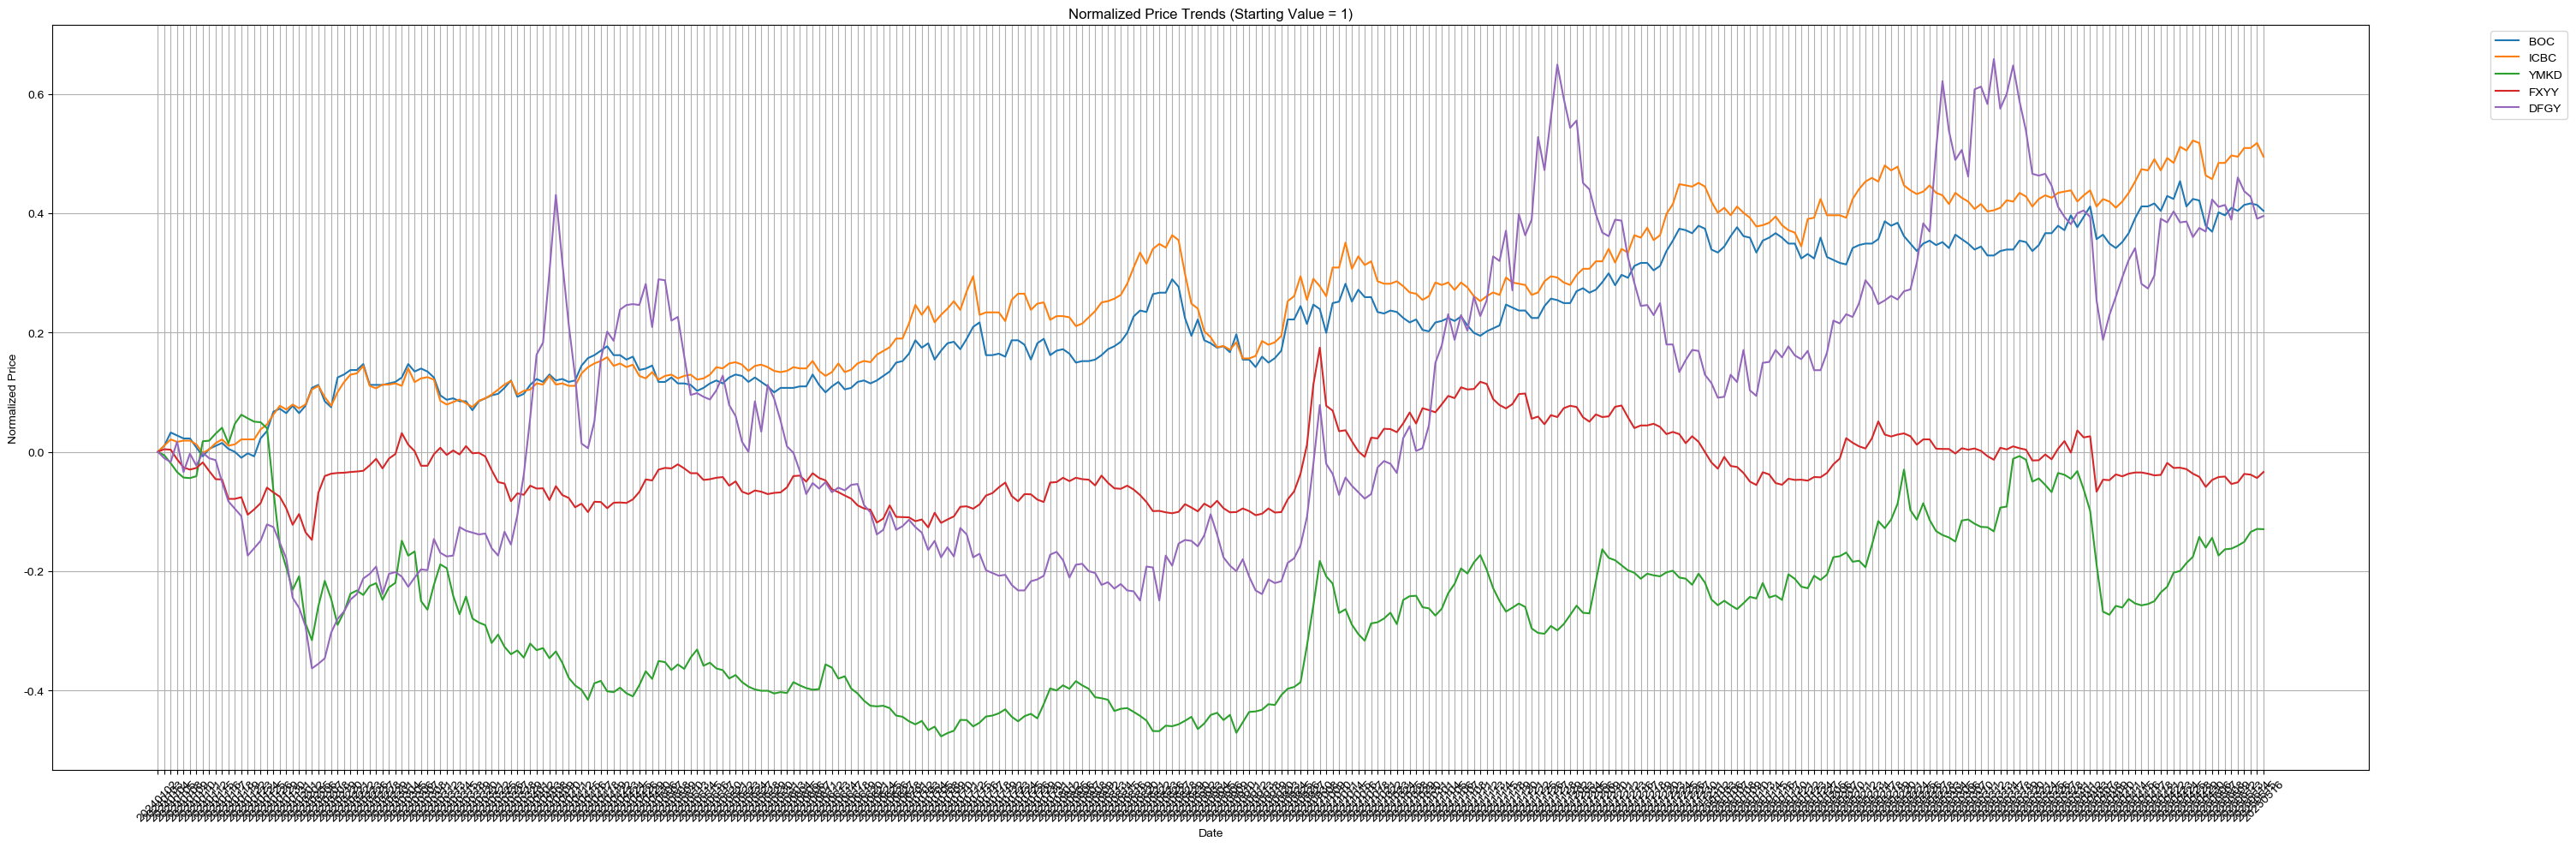

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize prices to start from 100
normalized_prices = merged_prices / merged_prices.iloc[0] - 1

# Set plot style

plt.figure(figsize=(30, 10))

# Plot normalized prices
for column in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[column], label=column)

# Customize the plot
plt.title('Normalized Price Trends (Starting Value = 1)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# (4)计算每支股票的收益与风险

In [92]:
import numpy as np

# 计算每日收益率
daily_returns = merged_prices.pct_change()

# 计算年化收益率 (假设一年250个交易日)
annual_returns = daily_returns.mean() * 250

# 计算年化风险
annual_risk = daily_returns.std() * np.sqrt(250)

# 创建收益风险汇总表
summary = pd.DataFrame({
    '年化收益率': annual_returns,
    '年化风险': annual_risk
})

# 显示结果
print("\n每日收益率的描述性统计：")
print(daily_returns.describe())
print("\n收益风险汇总：")
print(summary)



每日收益率的描述性统计：
              BOC        ICBC        YMKD        FXYY        DFGY
count  328.000000  328.000000  328.000000  328.000000  328.000000
mean     0.001121    0.001307    0.000029    0.000038    0.001733
std      0.013131    0.012709    0.030112    0.016932    0.038090
min     -0.045082   -0.050000   -0.100061   -0.090553   -0.100442
25%     -0.005903   -0.005671   -0.014412   -0.007923   -0.020496
50%      0.002079    0.001850   -0.002091   -0.000452   -0.001910
75%      0.008631    0.008536    0.014297    0.007737    0.019921
max      0.046404    0.048951    0.100076    0.100199    0.100484

收益风险汇总：
         年化收益率      年化风险
BOC   0.280262  0.207620
ICBC  0.326735  0.200954
YMKD  0.007346  0.476118
FXYY  0.009378  0.267724
DFGY  0.433146  0.602262


# (5).求解投资组合的最优组合

In [93]:
import numpy as np
from scipy.optimize import minimize

# 设置无风险利率(假设为3%)
risk_free_rate = 0.03

# 计算投资组合的收益率和风险
def portfolio_performance(weights, returns, cov_matrix):
    # 投资组合收益率
    portfolio_return = np.sum(returns.mean() * weights) * 250
    # 投资组合风险
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 250, weights)))
    # 夏普比率
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std
    return portfolio_return, portfolio_std, sharpe_ratio

# 最优化目标函数：最大化夏普比率
def neg_sharpe_ratio(weights):
    return -portfolio_performance(weights, daily_returns, daily_returns.cov())[2]

# 约束条件
constraints = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}  # 权重之和为1
)
bounds = tuple((0, 1) for _ in range(len(merged_prices.columns)))  # 权重在0和1之间

# 初始权重猜测
initial_weights = np.array([1/len(merged_prices.columns)] * len(merged_prices.columns))

# 求解最优组合
optimal_portfolio = minimize(neg_sharpe_ratio, 
                           initial_weights,
                           method='SLSQP',
                           bounds=bounds,
                           constraints=constraints)

# 获取最优权重
optimal_weights = optimal_portfolio.x

# 计算最优组合的表现
optimal_return, optimal_std, optimal_sharpe = portfolio_performance(
    optimal_weights, daily_returns, daily_returns.cov()
)

# 输出结果
print("\n最优投资组合:")
for stock, weight in zip(merged_prices.columns, optimal_weights):
    print(f"{stock}: {weight:.4f}")
print(f"\n预期年化收益率: {optimal_return:.4%}")
print(f"预期年化风险: {optimal_std:.4%}")
print(f"夏普比率: {optimal_sharpe:.4f}")


最优投资组合:
BOC: 0.0000
ICBC: 0.8467
YMKD: 0.0049
FXYY: 0.0000
DFGY: 0.1484

预期年化收益率: 34.0965%
预期年化风险: 18.3967%
夏普比率: 1.6903


# (6).画出投资组合的有效前沿

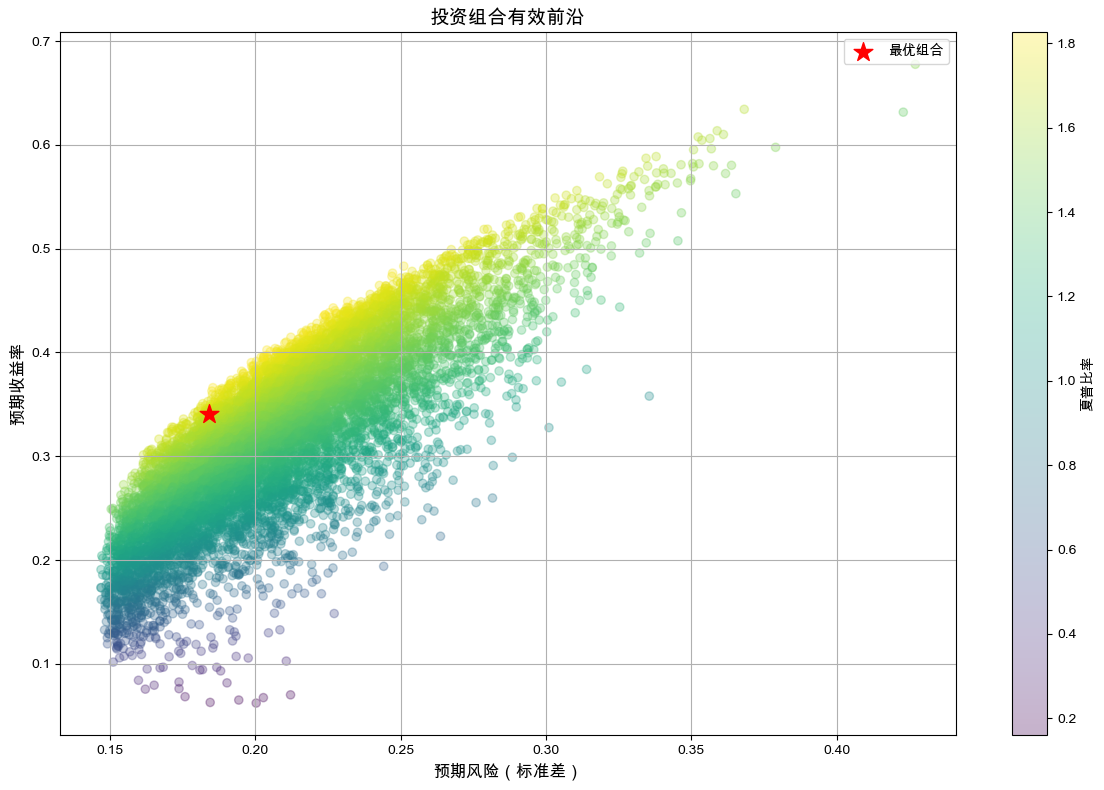

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac系统可用的中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题



# 绘制有效前沿
plt.figure(figsize=(12, 8))

# 绘制随机投资组合
scatter = plt.scatter(results[0,:], results[1,:], 
                     c=results[2,:], 
                     marker='o', 
                     cmap='viridis', 
                     alpha=0.3)

# 标记最优投资组合点
plt.scatter(optimal_std, optimal_return, 
           color='red', 
           marker='*', 
           s=200, 
           label='最优组合')


plt.colorbar(scatter, label='夏普比率')
plt.xlabel('预期风险（标准差）', fontsize=12)
plt.ylabel('预期收益率', fontsize=12)
plt.title('投资组合有效前沿', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)


plt.tight_layout()


plt.show()

# (7).从沪深300指数成分股中随机选择5-10只股票，画出他们的投资组合有效前沿

In [ ]:
import tushare as ts
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 获取沪深300成分股列表
pro = ts.pro_api('a394376ad4ede9c1214c06479e7d1bee32919045f909fcbfc39cabde')
hs300 = pro.index_weight(index_code='399300.SZ', 
                        start_date='20240102', 
                        end_date='20250516')

# 随机选择5-10只股票
n_stocks = random.randint(5, 10)
selected_stocks = random.sample(list(hs300['con_code']), n_stocks)

# 获取选中股票的数据
stock_data = {}
for stock in selected_stocks:
    df = pro.daily(ts_code=stock, 
                  start_date='20240102', 
                  end_date='20250516')
    stock_data[stock] = df[['trade_date', 'close']]

# 合并数据
merged_data = None
for stock, data in stock_data.items():
    if merged_data is None:
        merged_data = data.rename(columns={'close': stock})
    else:
        merged_data = merged_data.merge(
            data.rename(columns={'close': stock}),
            on='trade_date'
        )

# 设置日期索引
merged_data.set_index('trade_date', inplace=True)
merged_data.sort_index(inplace=True)

# 计算日收益率
daily_returns = merged_data.pct_change()

# 生成随机投资组合
def generate_portfolios(num_portfolios=5000):
    results = np.zeros((3, num_portfolios))
    for i in range(num_portfolios):
        weights = np.random.random(n_stocks)
        weights /= np.sum(weights)
        
        portfolio_return = np.sum(daily_returns.mean() * weights) * 250
        portfolio_std = np.sqrt(
            np.dot(weights.T, np.dot(daily_returns.cov() * 250, weights))
        )
        sharpe_ratio = (portfolio_return - 0.03) / portfolio_std
        
        results[0,i] = portfolio_std
        results[1,i] = portfolio_return
        results[2,i] = sharpe_ratio
    
    return results

# 生成投资组合数据
results = generate_portfolios()

# 绘制有效前沿
plt.figure(figsize=(12, 8))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

scatter = plt.scatter(results[0,:], 
                     results[1,:],
                     c=results[2,:],
                     marker='o',
                     cmap='viridis',
                     alpha=0.3)

plt.colorbar(scatter, label='夏普比率')
plt.xlabel('预期风险（标准差）', fontsize=12)
plt.ylabel('预期收益率', fontsize=12)
plt.title(f'随机选择{n_stocks}只沪深300成分股的投资组合有效前沿', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# 打印选中的股票代码
print("\n随机选中的股票：")
for stock in selected_stocks:
    print(stock)

Exception: 抱歉，您没有接口访问权限，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。

In [ ]:
import tushare as ts
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 获取沪深300成分股列表
pro = ts.pro_api('a394376ad4ede9c1214c06479e7d1bee32919045f909fcbfc39cabde')
hs300 = pro.index_weight(index_code='399300.SZ', 
                        start_date='20240102', 
                        end_date='20250516')

# 随机选择5-10只股票
n_stocks = random.randint(5, 10)
selected_stocks = random.sample(list(hs300['con_code']), n_stocks)

# 获取选中股票的数据
stock_data = {}
for stock in selected_stocks:
    df = pro.daily(ts_code=stock, 
                  start_date='20240102', 
                  end_date='20250516')
    stock_data[stock] = df[['trade_date', 'close']]

# 合并数据
merged_data = None
for stock, data in stock_data.items():
    if merged_data is None:
        merged_data = data.rename(columns={'close': stock})
    else:
        merged_data = merged_data.merge(
            data.rename(columns={'close': stock}),
            on='trade_date'
        )

# 设置日期索引
merged_data.set_index('trade_date', inplace=True)
merged_data.sort_index(inplace=True)

# 计算日收益率
daily_returns = merged_data.pct_change()

# 生成随机投资组合
def generate_portfolios(num_portfolios=5000):
    results = np.zeros((3, num_portfolios))
    for i in range(num_portfolios):
        weights = np.random.random(n_stocks)
        weights /= np.sum(weights)
        
        portfolio_return = np.sum(daily_returns.mean() * weights) * 250
        portfolio_std = np.sqrt(
            np.dot(weights.T, np.dot(daily_returns.cov() * 250, weights))
        )
        sharpe_ratio = (portfolio_return - 0.03) / portfolio_std
        
        results[0,i] = portfolio_std
        results[1,i] = portfolio_return
        results[2,i] = sharpe_ratio
    
    return results

# 生成投资组合数据
results = generate_portfolios()

# 绘制有效前沿
plt.figure(figsize=(12, 8))
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

scatter = plt.scatter(results[0,:], 
                     results[1,:],
                     c=results[2,:],
                     marker='o',
                     cmap='viridis',
                     alpha=0.3)

plt.colorbar(scatter, label='夏普比率')
plt.xlabel('预期风险（标准差）', fontsize=12)
plt.ylabel('预期收益率', fontsize=12)
plt.title(f'随机选择{n_stocks}只沪深300成分股的投资组合有效前沿', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# 打印选中的股票代码
print("\n随机选中的股票：")
for stock in selected_stocks:
    print(stock)

Exception: 抱歉，您没有接口访问权限，权限的具体详情访问：https://tushare.pro/document/1?doc_id=108。